# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [2]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [3]:
file_1 = "/content/Churn_Modelling.csv"

df = pd.read_csv(file_1)

print("Jeu de données chargé avec succès.")
print(f"Dimensions du jeu de données : {df.shape}")

print("\nLes 5 premières lignes :")
display(df.head())

print("\nListe des colonnes :")
print(df.columns.tolist())

Jeu de données chargé avec succès.
Dimensions du jeu de données : (10000, 14)

Les 5 premières lignes :


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



Liste des colonnes :
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [4]:
print("Informations sur le jeu de données :")
df.info()

print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())

print("\nNombre de doublons :")
print(df.duplicated().sum())

print("\nStatistiques descriptives :")
display(df.describe())

Informations sur le jeu de données :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

Valeurs manquantes par colonne :
RowNumber          0
Cu

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Nombre de clients restés dans la banque : 7963
Nombre de clients ayant quitté la banque : 2037

Répartition de la variable Exited :
Exited
0    7963
1    2037
Name: count, dtype: int64


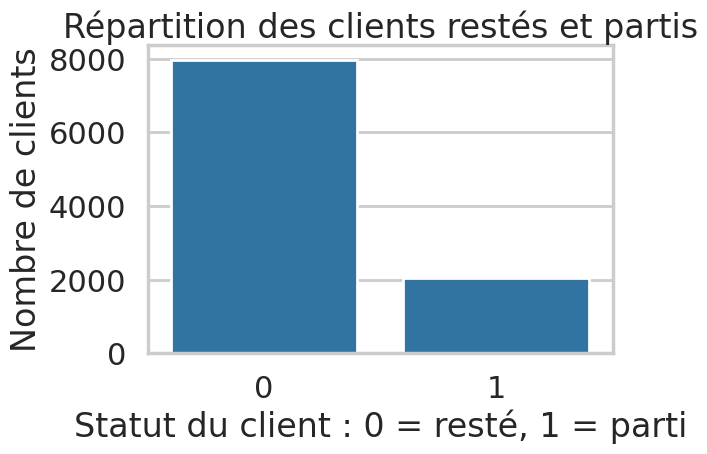

In [5]:
df_0 = df[df["Exited"] == 0]
df_1 = df[df["Exited"] == 1]

print("Nombre de clients restés dans la banque :", df_0.shape[0])
print("Nombre de clients ayant quitté la banque :", df_1.shape[0])

print("\nRépartition de la variable Exited :")
print(df["Exited"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Exited")
plt.title("Répartition des clients restés et partis")
plt.xlabel("Statut du client : 0 = resté, 1 = parti")
plt.ylabel("Nombre de clients")
plt.show()

## Hypothesis 1: Age

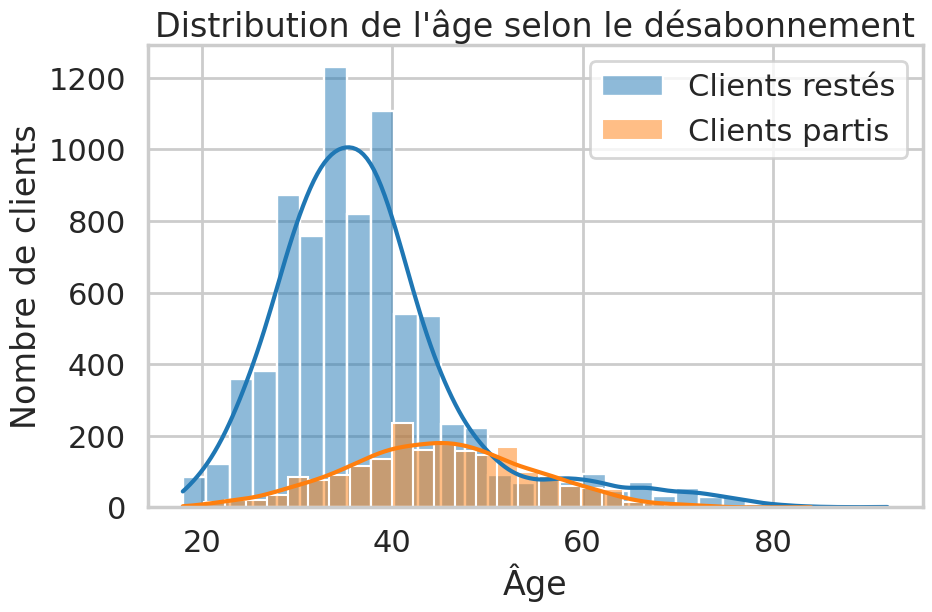

In [6]:
plt.figure(figsize=(10, 6))

sns.histplot(df_0["Age"], kde=True, label="Clients restés", bins=30)
sns.histplot(df_1["Age"], kde=True, label="Clients partis", bins=30)

plt.title("Distribution de l'âge selon le désabonnement")
plt.xlabel("Âge")
plt.ylabel("Nombre de clients")
plt.legend()
plt.show()

In [7]:
age_mean_0 = df_0["Age"].mean()
age_std_0 = df_0["Age"].std()

age_mean_1 = df_1["Age"].mean()
age_std_1 = df_1["Age"].std()

print("Clients restés dans la banque :")
print(f"Âge moyen : {age_mean_0:.2f}")
print(f"Écart-type de l'âge : {age_std_0:.2f}")

print("\nClients ayant quitté la banque :")
print(f"Âge moyen : {age_mean_1:.2f}")
print(f"Écart-type de l'âge : {age_std_1:.2f}")

Clients restés dans la banque :
Âge moyen : 37.41
Écart-type de l'âge : 10.13

Clients ayant quitté la banque :
Âge moyen : 44.84
Écart-type de l'âge : 9.76


In [8]:
t_stat_age, p_value_age = scipy.stats.ttest_ind(
    df_0["Age"],
    df_1["Age"],
    equal_var=False
)

alpha = 0.05

print("Test t de Student sur l'âge :")
print(f"Statistique t : {t_stat_age:.4f}")
print(f"Valeur p : {p_value_age:.6f}")

if p_value_age < alpha:
    print("Conclusion : on rejette H0.")
    print("L'âge moyen des clients restés et des clients partis est significativement différent.")
else:
    print("Conclusion : on ne rejette pas H0.")
    print("Il n'y a pas de différence significative d'âge entre les deux groupes.")

Test t de Student sur l'âge :
Statistique t : -30.4192
Valeur p : 0.000000
Conclusion : on rejette H0.
L'âge moyen des clients restés et des clients partis est significativement différent.


### Using Bootstrapping

In [9]:
def bs_choice(data, func, size):
    bs_s = np.empty(size)

    for i in range(size):
        bs_abc = np.random.choice(data, size=len(data), replace=True)
        bs_s[i] = func(bs_abc)

    return bs_s

In [10]:
age_0 = df_0["Age"].values
age_1 = df_1["Age"].values

observed_diff_age = np.mean(age_1) - np.mean(age_0)

combined_age_mean = np.mean(np.concatenate([age_0, age_1]))

age_0_shifted = age_0 - np.mean(age_0) + combined_age_mean
age_1_shifted = age_1 - np.mean(age_1) + combined_age_mean

print("Différence observée des moyennes d'âge :")
print(f"{observed_diff_age:.4f}")

Différence observée des moyennes d'âge :
7.4296


In [11]:
np.random.seed(42)

bs_age_0 = bs_choice(age_0_shifted, np.mean, 10000)
bs_age_1 = bs_choice(age_1_shifted, np.mean, 10000)

bs_diff_age = bs_age_1 - bs_age_0

print("Écart-type de la distribution bootstrap :")
print(f"{np.std(bs_diff_age):.4f}")

Écart-type de la distribution bootstrap :
0.2431


In [12]:
p_value_boot_age = np.mean(np.abs(bs_diff_age) >= np.abs(observed_diff_age))

print("Valeur p obtenue par bootstrapping pour l'âge :")
print(f"{p_value_boot_age:.6f}")

if p_value_boot_age < alpha:
    print("Conclusion : on rejette H0.")
    print("La différence d'âge entre les deux groupes est significative.")
else:
    print("Conclusion : on ne rejette pas H0.")
    print("La différence d'âge n'est pas significative.")

Valeur p obtenue par bootstrapping pour l'âge :
0.000000
Conclusion : on rejette H0.
La différence d'âge entre les deux groupes est significative.


### Conclusion
on rejette H0

## Hypothesis 2: Credit Score

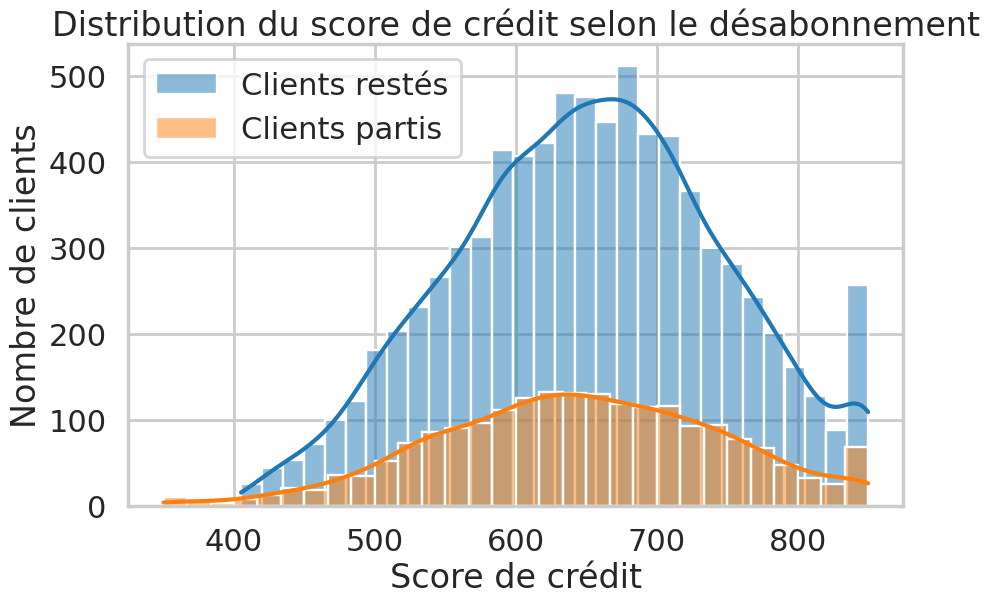

In [13]:
plt.figure(figsize=(10, 6))

sns.histplot(df_0["CreditScore"], kde=True, label="Clients restés", bins=30)
sns.histplot(df_1["CreditScore"], kde=True, label="Clients partis", bins=30)

plt.title("Distribution du score de crédit selon le désabonnement")
plt.xlabel("Score de crédit")
plt.ylabel("Nombre de clients")
plt.legend()
plt.show()

In [14]:
t_stat_credit, p_value_credit = scipy.stats.ttest_ind(
    df_0["CreditScore"],
    df_1["CreditScore"],
    equal_var=False
)

print("Test t de Student sur le score de crédit :")
print(f"Statistique t : {t_stat_credit:.4f}")
print(f"Valeur p : {p_value_credit:.6f}")

if p_value_credit < alpha:
    print("Conclusion : on rejette H0.")
    print("Le score de crédit moyen est significativement différent entre les deux groupes.")
else:
    print("Conclusion : on ne rejette pas H0.")
    print("Il n'y a pas de différence significative du score de crédit entre les deux groupes.")

Test t de Student sur le score de crédit :
Statistique t : 2.6347
Valeur p : 0.008465
Conclusion : on rejette H0.
Le score de crédit moyen est significativement différent entre les deux groupes.


## Hypothesis 3: Balance

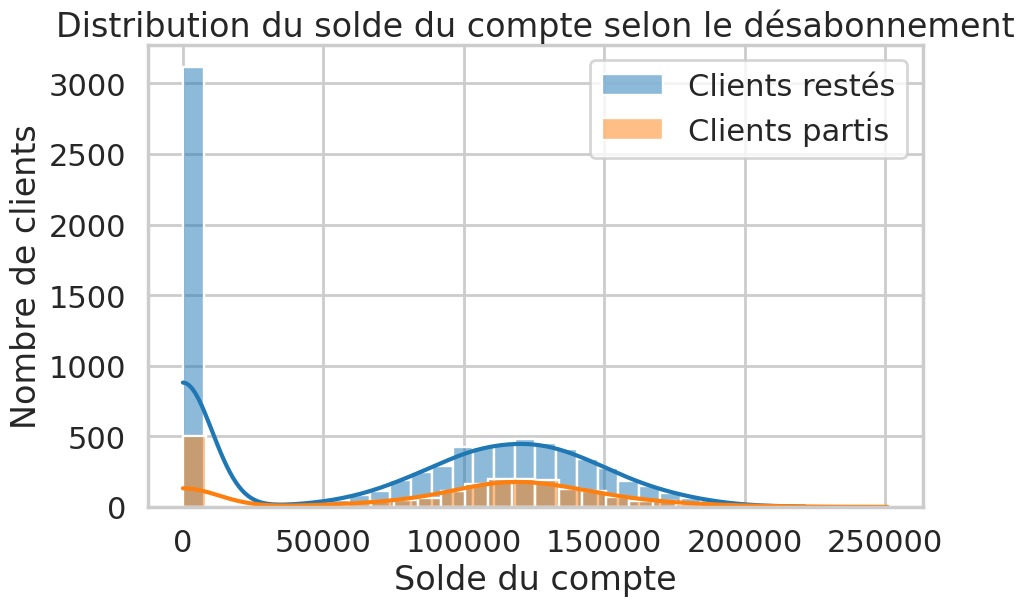

In [15]:
plt.figure(figsize=(10, 6))

sns.histplot(df_0["Balance"], kde=True, label="Clients restés", bins=30)
sns.histplot(df_1["Balance"], kde=True, label="Clients partis", bins=30)

plt.title("Distribution du solde du compte selon le désabonnement")
plt.xlabel("Solde du compte")
plt.ylabel("Nombre de clients")
plt.legend()
plt.show()

In [16]:
t_stat_balance, p_value_balance = scipy.stats.ttest_ind(
    df_0["Balance"],
    df_1["Balance"],
    equal_var=False
)

print("Test t de Student sur le solde du compte :")
print(f"Statistique t : {t_stat_balance:.4f}")
print(f"Valeur p : {p_value_balance:.6f}")

if p_value_balance < alpha:
    print("Conclusion : on rejette H0.")
    print("Le solde moyen est significativement différent entre les clients restés et les clients partis.")
else:
    print("Conclusion : on ne rejette pas H0.")
    print("Il n'y a pas de différence significative de solde entre les deux groupes.")

Test t de Student sur le solde du compte :
Statistique t : -12.4713
Valeur p : 0.000000
Conclusion : on rejette H0.
Le solde moyen est significativement différent entre les clients restés et les clients partis.


## Hypothesis 4: Estimated Salary

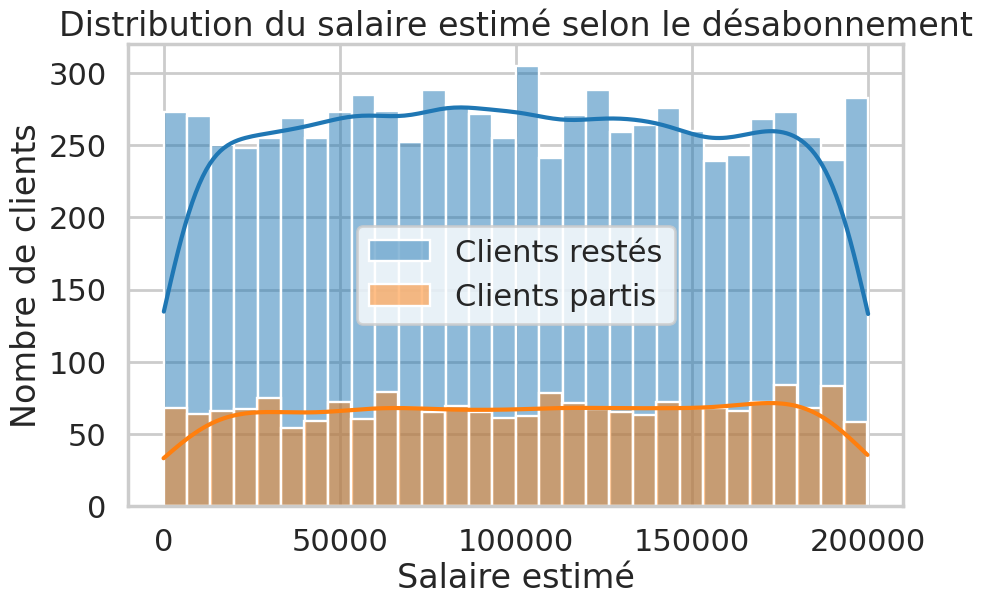

In [17]:
plt.figure(figsize=(10, 6))

sns.histplot(df_0["EstimatedSalary"], kde=True, label="Clients restés", bins=30)
sns.histplot(df_1["EstimatedSalary"], kde=True, label="Clients partis", bins=30)

plt.title("Distribution du salaire estimé selon le désabonnement")
plt.xlabel("Salaire estimé")
plt.ylabel("Nombre de clients")
plt.legend()
plt.show()

In [18]:
t_stat_salary, p_value_salary = scipy.stats.ttest_ind(
    df_0["EstimatedSalary"],
    df_1["EstimatedSalary"],
    equal_var=False
)

print("Test t de Student sur le salaire estimé :")
print(f"Statistique t : {t_stat_salary:.4f}")
print(f"Valeur p : {p_value_salary:.6f}")

if p_value_salary < alpha:
    print("Conclusion : on rejette H0.")
    print("Le salaire estimé moyen est significativement différent entre les clients restés et les clients partis.")
else:
    print("Conclusion : on ne rejette pas H0.")
    print("Il n'y a pas de différence significative du salaire estimé entre les deux groupes.")

Test t de Student sur le salaire estimé :
Statistique t : -1.2034
Valeur p : 0.228925
Conclusion : on ne rejette pas H0.
Il n'y a pas de différence significative du salaire estimé entre les deux groupes.


### Using Bootstrapping

In [19]:
# Fonction de bootstrapping

def bs_choice(data, func, size):
    bs_s = np.empty(size)

    for i in range(size):
        bs_sample = np.random.choice(data, size=len(data), replace=True)
        bs_s[i] = func(bs_sample)

    return bs_s

In [20]:


age_0 = df_0["Age"].values
age_1 = df_1["Age"].values

observed_diff_age = np.mean(age_1) - np.mean(age_0)

print("Différence observée entre les moyennes d'âge :")
print(f"{observed_diff_age:.4f}")

combined_age_mean = np.mean(np.concatenate([age_0, age_1]))

age_0_shifted = age_0 - np.mean(age_0) + combined_age_mean
age_1_shifted = age_1 - np.mean(age_1) + combined_age_mean

np.random.seed(42)

bs_age_0 = bs_choice(age_0_shifted, np.mean, 10000)
bs_age_1 = bs_choice(age_1_shifted, np.mean, 10000)

bs_diff_age = bs_age_1 - bs_age_0

print("Bootstrapping terminé.")
print("Écart-type de la distribution bootstrap :")
print(f"{np.std(bs_diff_age):.4f}")

Différence observée entre les moyennes d'âge :
7.4296
Bootstrapping terminé.
Écart-type de la distribution bootstrap :
0.2431


In [21]:

p_value_boot_age = np.mean(np.abs(bs_diff_age) >= np.abs(observed_diff_age))

print("Valeur p obtenue par bootstrapping pour l'âge :")
print(f"{p_value_boot_age:.6f}")

alpha = 0.05

if p_value_boot_age < alpha:
    print("Conclusion : on rejette H0.")
    print("La différence d'âge entre les clients restés et les clients partis est statistiquement significative.")
else:
    print("Conclusion : on ne rejette pas H0.")
    print("La différence d'âge entre les deux groupes n'est pas statistiquement significative.")

Valeur p obtenue par bootstrapping pour l'âge :
0.000000
Conclusion : on rejette H0.
La différence d'âge entre les clients restés et les clients partis est statistiquement significative.


## Final Conclusion


La variable la plus utile pour prédire le désabonnement est probablement l’âge.
D’après le test d’hypothèse, l’âge moyen des clients qui ont quitté la banque est significativement différent de celui des clients qui sont restés. Comme la valeur p est inférieure à 0.05, on rejette l’hypothèse nulle. Cela montre que l’âge est fortement lié au désabonnement et peut être une variable importante pour prédire si un client va quitter la banque.